
<p style="text-align: center;">ЛАБОРАТОРНАЯ №2</p>

<p style="text-align: center;">СТРАТЕГИИ ТЕОРИИ СТАТИСТИЧЕСКОГО РАСПОЗНАВАНИЯ ОБРАЗОВ</p>


- **Вариант: №3** 
- **Выполнили: Богачев Матвей и Чумаков Иван**
- **Группа 6511**

## Исходные данные 
1. 2 файла, содержащих  наборы  двумерных  нормально  распределенных векторов  признаков  для ситуации  равных  корреляционных матриц; параметры этих законов распределения.

2. 3 Файла содержащих  наборы  двумерных  нормально  распределенных векторов признаков для ситуации **неравных** корреляционных матриц; параметры этих законов распределения

# Задания: 
1. Построить  байесовскую  решающую  границу  между  классами $\Omega_0$
 и $\Omega_1$  двумерных нормально распределенных векторов признаков  для  случая  равных  корреляционных  матриц  и  равных априорных вероятностей  и изобразить ее графически. Вычислить вероятности ошибочной классификации и суммарную вероятность ошибочной классификации в этом случае. 
2. Построить  минимаксный  классификатор  и  классификатор 
Неймана-Пирсона  для  вероятности  ошибки  первого  рода $p^*_0 = 0.05$ для  двух  классов $\Omega_0$ и $\Omega_1$ двумерных  нормально распределенных  векторов признаков  в случае  равных  корреляционных матриц. Изобразить решающие границы полученных классификаторов графически. 
3. Построить байесовскую решающую границу между классами $\Omega_0$ $\Omega_1$  $\Omega_2$, двумерных нормально распределенных векторов признаков для неравных корреляционных матриц и равных априорных вероятностей. Изобразить полученные решающие границы графически. Для любых двух классов оценить экспериментально  вероятности  ошибочной  классификации в этом случае и определить относительную погрешность полученных оценок для заданного объема обучающей выборки N.  Определить объем обучающей выборки, обеспечивающий получение  оценок  вероятностей  ошибочной  классификации с погрешностью не более 5%. 
4. Построить  байесовскую  разделяющую  границу  между  классами $\Omega_0$  и $\Omega_1$  двумерных бинарных векторов признаков. Вычислить  вероятности  ошибочной  классификации  аналитически и оценить их экспериментально.

In [45]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple

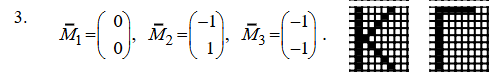

In [46]:
def get_mean(X: np.ndarray, N: int) -> np.ndarray:
    return np.sum(X, axis=0) / N

def get_var(X: np.ndarray, N: int) -> np.ndarray:
    variances = []
    for row in X.transpose():
        mean = sum(row) / N
        var = sum((x - mean) ** 2 for x in row) / (N - 1)
        variances.append(var)

    return np.array(variances)

def get_cov(X: np.ndarray) -> np.ndarray:
    X1 = X.transpose()
    num_rows, num_cols = X1.shape
    
    means = np.array([sum(X1[i]) / num_cols for i in range(num_rows)])
    
    cov_matrix = np.zeros((num_rows, num_rows))
    
    for i in range(num_rows):
        for j in range(num_rows):
            cov = sum((X1[i, k] - means[i]) * (X1[j, k] - means[j]) for k in range(num_cols)) / (num_cols - 1)
            cov_matrix[i, j] = cov

    return np.array(cov_matrix)

# def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B: np.ndarray) -> np.ndarray:
#     return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2: np.ndarray | None = None) -> np.ndarray:
    if B2 is None:
        B = B1
    else:
        B = (B1 + B2) / 2

    return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

def get_dist_Bhattacharyya(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2: np.ndarray) -> np.ndarray:
    B = (B1 + B2) / 2
    
    return 0.25 * np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2)) + \
           0.5 * np.log(np.linalg.det(B) / np.sqrt(np.linalg.det(B1) * np.linalg.det(B2)))


In [47]:
# Параметры 
M1 = np.array([[0], 
               [0]])

M2 = np.array([[-1], 
               [1]])

M3 = np.array([[-1], 
               [-1]])

B1 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

B2 = np.array([[0.3, 0.1],
               [0.1, 0.3]])

B3 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

X1_equal = np.load("data/Equal_cov/X1_equal.npy")
X2_equal = np.load("data/Equal_cov/X2_equal.npy")

X1_unequal = np.load("data/Unequal/X1_unequal.npy")
X2_unequal = np.load("data/Unequal/X2_unequal.npy")
X3_unequal = np.load("data/Unequal/X3_unequal.npy")

n = 200


In [48]:
meanX1_equal = get_mean(X1_equal, n)
meanX2_equal = get_mean(X2_equal, n)

varX1_equal = get_var(X1_equal, n)
varX2_equal = get_var(X2_equal, n)  

covX1_equal = get_cov(X1_equal) 
covX2_equal = get_cov(X2_equal) 

dist_Mahalanobis = float(get_dist_Mahalanobis(meanX1_equal, meanX1_equal, covX1_equal))

meanX1_unequal = get_mean(X1_unequal, n)
meanX2_unequal = get_mean(X2_unequal, n)
meanX3_unequal = get_mean(X3_unequal, n)

varX1_unequal = get_var(X1_unequal, n)
varX2_unequal = get_var(X2_unequal, n)
varX3_unequal = get_var(X3_unequal, n)

covX1_unequal = get_cov(X1_unequal) 
covX2_unequal = get_cov(X2_unequal) 
covX3_unequal = get_cov(X3_unequal) 

In [49]:
def Bayes_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(prob1 / prob2)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Min_Max_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        lambda1: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(lambda1)

    y = (-a[0] * x - b) / a[1]

    return x, y

def Neyman_Pearson_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        p0: float, dist: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.linspace(min, max, 200)

    lambda_ln = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + lambda_ln

    y = (-a[0] * x - b) / a[1]

    return x, y

def compute_prob_errors(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    lambda1 = np.log(prob1 / prob2)

    err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))
    err = prob1 * err_I + prob2 * err_II

    return err_I, err_II, err

# Задание 1
Построить  байесовскую  решающую  границу  между  классами $\Omega_0$ и $\Omega_1$  двумерных нормально распределенных векторов признаков  для  случая  равных  корреляционных  матриц  и  равных априорных вероятностей  и изобразить ее графически. Вычислить вероятности ошибочной классификации и суммарную вероятность ошибочной классификации в этом случае.

In [50]:
covX1_X2_equal = ((n-1)*covX1_equal + (n-1)*covX2_equal) / (2*n - 2)

C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2772474297.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_Min_Max, y_Min_Max, 'k-', label='Минимаксный критерий', color="black")
C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2772474297.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_Neyman_Pirson, y_Neyman_Pirson, 'k-', label='Критерий Неймана-Пирсона', color="green")
C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2772474297.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(x_Bayes, y_Bayes, 'k-', label='Критерий Байеса', color="red", linestyle='--')
C:\Users\boga4\AppData\Local\Temp\ipyker

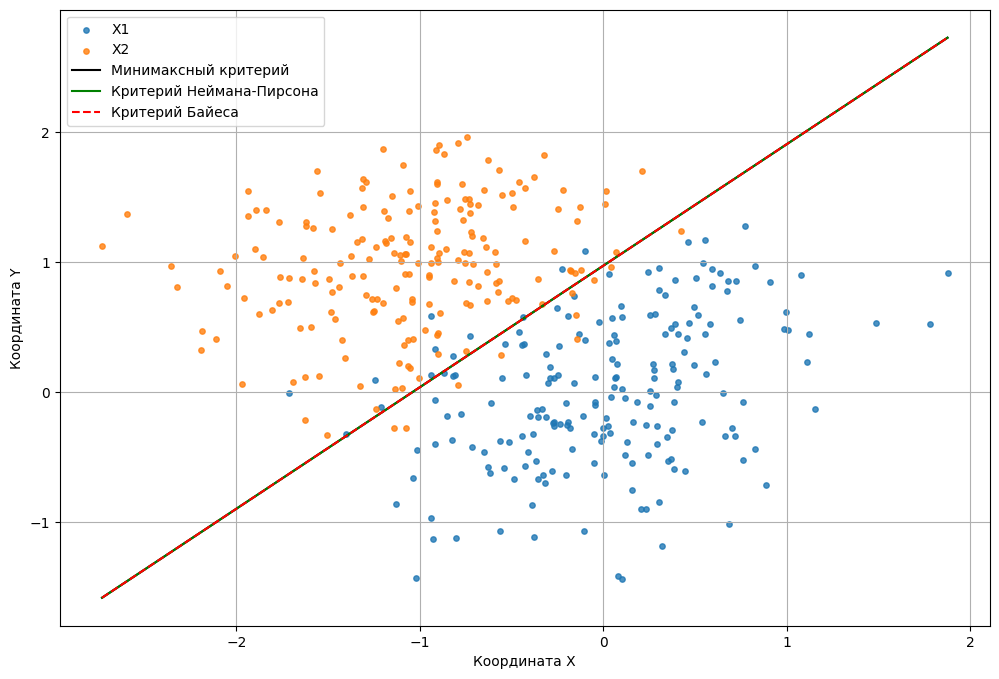

In [51]:
min_X1_X2 = np.min(np.concatenate((X1_equal[:, 0], X2_equal[:, 0])))
max_X1_X2 = np.max(np.concatenate((X1_equal[:, 0], X2_equal[:, 0])))
prob1 = 0.5
prob2 = 1 - prob1

p0 = 0.05
lambda1 = 1

x_Bayes, y_Bayes = Bayes_Classificator(meanX1_equal, meanX2_equal, covX1_X2_equal, min_X1_X2, max_X1_X2, prob1, prob2)  
x_Min_Max, y_Min_Max = Min_Max_Classificator(meanX1_equal, meanX2_equal, covX1_X2_equal, min_X1_X2, max_X1_X2, lambda1)
x_Neyman_Pirson, y_Neyman_Pirson = Neyman_Pearson_Classificator(meanX1_equal, meanX2_equal, covX1_X2_equal, min_X1_X2, max_X1_X2, p0, dist_Mahalanobis)

plt.figure(figsize=(12,8))
plt.scatter(X1_equal[:,0], X1_equal[:,1], s=15, label='X1', alpha=0.8)
plt.scatter(X2_equal[:,0], X2_equal[:,1], s=15, label='X2', alpha=0.8)

plt.plot(x_Min_Max, y_Min_Max, 'k-', label='Минимаксный критерий', color="black")
plt.plot(x_Neyman_Pirson, y_Neyman_Pirson, 'k-', label='Критерий Неймана-Пирсона', color="green")
plt.plot(x_Bayes, y_Bayes, 'k-', label='Критерий Байеса', color="red", linestyle='--')
plt.legend()
plt.xlabel('Координата Х')
plt.ylabel('Координата Y')
plt.grid(True)

plt.show()

# Задание 2. 
Построить  минимаксный  классификатор  и  классификатор Неймана-Пирсона  для  вероятности  ошибки  первого  рода $p^*_0 = 0.05$ для  двух  классов $\Omega_0$ и $\Omega_1$ двумерных  нормально распределенных  векторов признаков  в случае  равных  корреляционных матриц. Изобразить решающие границы полученных классификаторов графически.

In [52]:
def fit_line_from_points(x: np.ndarray, y: np.ndarray) -> tuple:
    a, b = np.polyfit(x, y, deg=1)
    eq = f'y = {a:.6f} * x + {b:.6f}'

    return float(a), float(b), eq


def compute_prob_errors_Bayes(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    lambda1 = np.log(prob1 / prob2)

    err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))
    err = prob1 * err_I + prob2 * err_II

    return err_I, err_II, err


def compute_prob_errors_Min_Max(dist: float, lambda1: float ) -> Tuple[float, float]:
    lambda_ln = np.log(lambda1)

    err_I = float(1 - norm.cdf((lambda_ln + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda_ln - 0.5 * dist) / np.sqrt(dist)))

    return err_I, err_II


def compute_prob_errors_Neyman_Pearson(dist: float, p0: float) -> Tuple[float, float]:
    lambda_ln = -0.5 * dist + np.sqrt(dist) * norm.ppf(1 - p0)

    err_I = float(1 - norm.cdf((lambda_ln + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda_ln - 0.5 * dist) / np.sqrt(dist)))

    return err_I, err_II


def compute_number_errors(X1: np.ndarray, X2: np.ndarray, 
                          coef_a: float, coef_b: float) -> Tuple[float, float, float, int]:
    n = X1.shape[0]
    
    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] + coef_b > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] + coef_b < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)  

    err = (count_errors_I + count_errors_II) / (2*n) 
    err_eps = np.sqrt((1 - err) / (n*err))

    n = (1 - err) / (err * np.power(0.05, 2))

    return err_I, err_II, err_eps, int(n)

In [53]:
p0_Bayes, p1_Bayes, p_Bayes = compute_prob_errors_Bayes(dist_Mahalanobis, prob1, prob2)
print(f"Вероятность ошибки первого рода: {p0_Bayes:.3f}")
print(f"Вероятность ошибки второго рода: {p1_Bayes:.3f}")
print(f"Общий риск: {p_Bayes:.3f}")

Вероятность ошибки первого рода: nan
Вероятность ошибки второго рода: nan
Общий риск: nan


C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:11: RuntimeWarning: invalid value encountered in scalar divide
  err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:12: RuntimeWarning: invalid value encountered in scalar divide
  err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))


In [54]:
a, b, eq = fit_line_from_points(x_Bayes, y_Bayes)

p0_Bayes_exp, p1_Bayes_exp, eps_Bayes, n_Bayes = compute_number_errors(X1_equal, X2_equal, a, b)
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Bayes_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Bayes_exp:.3f}")
print(f"Относительная погрешность ошибки: {eps_Bayes:.3f}")
print(f"Объем выборки для огрешности не более 0.05: {n_Bayes}")

Экспериментальная вероятность ошибки первого рода: 0.940
Экспериментальная вероятность ошибки второго рода: 0.950
Относительная погрешность ошибки: 0.017
Объем выборки для огрешности не более 0.05: 23


In [55]:
p0_Min_Max, p1_Min_Max = compute_prob_errors_Min_Max(dist_Mahalanobis, lambda1)
print(f"Вероятность ошибки первого рода: {p0_Min_Max:.3f}")
print(f"Вероятность ошибки второго рода: {p1_Min_Max:.3f}")

Вероятность ошибки первого рода: nan
Вероятность ошибки второго рода: nan


C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:21: RuntimeWarning: invalid value encountered in scalar divide
  err_I = float(1 - norm.cdf((lambda_ln + 0.5 * dist) / np.sqrt(dist)))
C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:22: RuntimeWarning: invalid value encountered in scalar divide
  err_II = float(norm.cdf((lambda_ln - 0.5 * dist) / np.sqrt(dist)))


In [56]:
a, b, eq = fit_line_from_points(x_Min_Max, y_Min_Max)

p0_Min_Max_exp, p1_Min_Max_exp, eps_Min_Max, n_Min_Max = compute_number_errors(X1_equal, X2_equal, a, b)
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Min_Max_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Min_Max_exp:.3f}")
print(f"Относительная погрешность ошибки: {eps_Min_Max:.3f}")
print(f"Объем выборки для огрешности не более 0.05: {n_Min_Max}")

Экспериментальная вероятность ошибки первого рода: 0.940
Экспериментальная вероятность ошибки второго рода: 0.950
Относительная погрешность ошибки: 0.017
Объем выборки для огрешности не более 0.05: 23


In [57]:
p0_Neyman_Pearson, p1_Neyman_Pearson = compute_prob_errors_Neyman_Pearson(dist_Mahalanobis, p0)
print(f"Вероятность ошибки первого рода: {p0_Neyman_Pearson:.3f}")
print(f"Вероятность ошибки второго рода: {p1_Neyman_Pearson:.3f}")

Вероятность ошибки первого рода: nan
Вероятность ошибки второго рода: nan


C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:30: RuntimeWarning: invalid value encountered in scalar divide
  err_I = float(1 - norm.cdf((lambda_ln + 0.5 * dist) / np.sqrt(dist)))
C:\Users\boga4\AppData\Local\Temp\ipykernel_15204\2532814001.py:31: RuntimeWarning: invalid value encountered in scalar divide
  err_II = float(norm.cdf((lambda_ln - 0.5 * dist) / np.sqrt(dist)))


In [58]:
a, b, eq = fit_line_from_points(x_Neyman_Pirson, y_Neyman_Pirson)

p0_Neyman_Pearson_exp, p1_Neyman_Pearson_exp, eps_Neyman_Pearson, n_Neyman_Pirson = compute_number_errors(X1_equal, X2_equal, a, b)
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Neyman_Pearson_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Neyman_Pearson_exp:.3f}")
print(f"Относительная погрешность ошибки: {eps_Neyman_Pearson:.3f}")
print(f"Объем выборки для огрешности не более 0.05: {n_Neyman_Pirson}")

Экспериментальная вероятность ошибки первого рода: 0.940
Экспериментальная вероятность ошибки второго рода: 0.950
Относительная погрешность ошибки: 0.017
Объем выборки для огрешности не более 0.05: 23


# Задание 3. 
Построить байесовскую решающую границу между классами $\Omega_0$ $\Omega_1$  $\Omega_2$, двумерных нормально распределенных векторов признаков для неравных корреляционных матриц и равных априорных вероятностей. Изобразить полученные решающие границы графически. Для любых двух классов оценить экспериментально  вероятности  ошибочной  классификации в этом случае и определить относительную погрешность полученных оценок для заданного объема обучающей выборки N.  Определить объем обучающей выборки, обеспечивающий получение  оценок  вероятностей  ошибочной  классификации с погрешностью не более 5%.

In [59]:
def get_row_for_2_classes_for_x(M1, M2, B1, B2, x):
    A = 0.5 * (np.linalg.inv(B2) - np.linalg.inv(B1))
    
    b = np.dot(np.transpose(M1), np.linalg.inv(B1)) - np.dot(np.transpose(M2), np.linalg.inv(B2))
    c = (np.dot(np.dot(0.5 * M2.transpose(), np.linalg.inv(B2)), M2) \
         + np.dot(np.dot(-0.5 * M1.transpose(), np.linalg.inv(B1)), M1)
         + 0.5 * np.log(np.linalg.det(B2) / np.linalg.det(B1)))
    
    coeff_y = (A[1][0] * x + A[0][1] * x + b[0][1]) / A[1][1]
    coeff_c = (A[0][0] * x * x + b[0][0] * x + c[0][0]) / A[1][1]

    D = np.power(coeff_y, 2) - 4 * 1 * coeff_c

    y1 = (- coeff_y[D >= 0] + np.sqrt(D[D >= 0])) / 2
    y2 = (- coeff_y[D >= 0] - np.sqrt(D[D >= 0])) / 2

    return x[D > 0], y1, y2

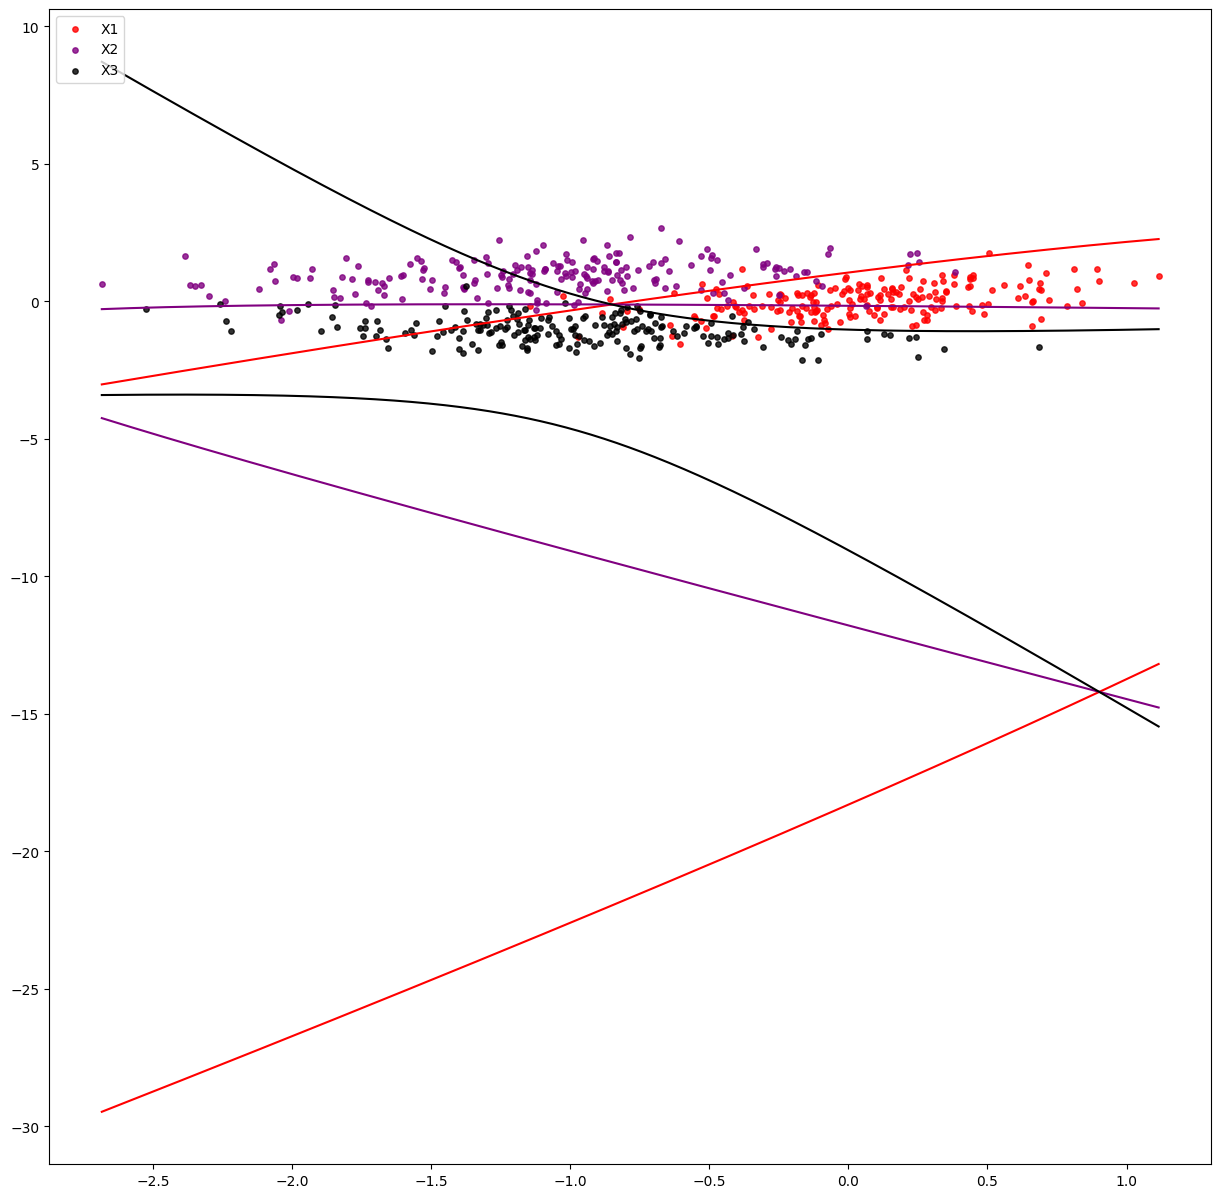

In [60]:
min_X1_X2 = np.min(np.concatenate((X1_unequal[:, 0], X2_unequal[:, 0])))
max_X1_X2 = np.max(np.concatenate((X1_unequal[:, 0], X2_unequal[:, 0])))

min_X2_X3 = np.min(np.concatenate((X2_unequal[:, 0], X3_unequal[:, 0])))
max_X2_X3 = np.max(np.concatenate((X2_unequal[:, 0], X3_unequal[:, 0])))

min_X1_X3 = np.min(np.concatenate((X1_unequal[:, 0], X3_unequal[:, 0])))
max_X1_X3 = np.max(np.concatenate((X1_unequal[:, 0], X3_unequal[:, 0])))

meanX1_2 = get_mean(X1_unequal, n)
meanX2_2 = get_mean(X2_unequal, n)
meanX3_2 = get_mean(X3_unequal, n)

meanX1_2_T = meanX1_2.reshape(-1, 1)
meanX2_2_T = meanX2_2.reshape(-1, 1)
meanX3_2_T = meanX3_2.reshape(-1, 1)

covX1_2 = get_cov(X1_unequal) 
covX2_2 = get_cov(X2_unequal) 
covX3_2 = get_cov(X3_unequal) 

min1 = np.min([min_X1_X2, min_X2_X3, min_X1_X3])
max1 = np.max([max_X1_X2, max_X2_X3, max_X1_X3])

x1 = np.linspace(min1, max1, 500)
x1, y1, y12 = get_row_for_2_classes_for_x(meanX1_2_T, meanX2_2_T, covX1_2, covX2_2, x1)

x2 = np.linspace(min1, max1, 500)
x2, y21, y22 = get_row_for_2_classes_for_x(meanX2_2_T, meanX3_2_T, covX2_2, covX3_2, x2)

x3 = np.linspace(min1, max1, 500)
x3, y31, y32 = get_row_for_2_classes_for_x(meanX1_2_T, meanX3_2_T, covX1_2, covX3_2, x3)

plt.figure(figsize=(15, 15))

plt.scatter(X1_unequal[:,0], X1_unequal[:,1], s=15, label='X1', alpha=0.8, color="red")
plt.scatter(X2_unequal[:,0], X2_unequal[:,1], s=15, label='X2', alpha=0.8, color="purple")
plt.scatter(X3_unequal[:,0], X3_unequal[:,1], s=15, label='X3', alpha=0.8, color="black")

plt.plot(x1, y1, color='red')
plt.plot(x1, y12, color='red')
plt.plot(x2, y21, color='purple')
plt.plot(x2, y22, color='purple')
plt.plot(x3, y31, color='black')
plt.plot(x3, y32, color='black')
plt.legend(loc="upper left")

plt.show()

# Задание 4. 
Построить  байесовскую  разделяющую  границу  между  классами $\Omega_0$  и $\Omega_1$  двумерных бинарных векторов признаков. Вычислить  вероятности  ошибочной  классификации  аналитически и оценить их экспериментально.